
# StackEval Benchmark Recreation - Human Scoring Analysis

## Professional notebook for the final human evaluation results

This notebook analyzes the human scoring phase of the **StackEval Benchmark recreation** project.  
The project recreates a smaller version of StackEval by using **real coding questions**, collecting answers from **four LLMs**, and evaluating those answers with **human scorers** on a **0-3 rubric**. The project goal is to understand which models are most useful on practical developer questions rather than only on academic benchmarks.

### Project context
- **Scorer 1:** Fatih - 4th semester GenAI student
- **Scorer 2:** Ömer Faruk - 8th semester internship student
- **Evaluation design:** 30 questions x 4 models x 2 scorers = 240 scored answers
- **Models compared:** GPT-5.4, Claude Sonnet 4.6, Llama 4 Maverick, GPT-5.4-mini

### Main questions in this notebook
1. Which model performed best and worst overall?
2. How close were the two scorers to each other?
3. Were the scoring differences small or large?
4. What are the most interesting findings for the project report and portfolio?

### Why the combined file matters
For **overall model ranking**, the mixed file is the correct basis because it combines both human perspectives into one evaluation dataset.  
For **scorer comparison**, the individual files still matter because they show whether the two evaluators judged the answers similarly or differently.


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.metrics import cohen_kappa_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# Put these three Excel files in the SAME folder as this notebook:
# - human_scores.xlsx
# - human_scoresv2.xlsx
# - combined_human_scores.xlsx
#
# If your files are somewhere else, replace the names below with full paths, for example:
# fatih_path = Path(r"C:\Users\koran\Desktop\human_scores.xlsx")

fatih_path = Path("human_scores.xlsx")
omer_path = Path("human_scoresv2.xlsx")
combined_path = Path("combined_human_scores.xlsx")

required_files = [fatih_path, omer_path, combined_path]
missing_files = [str(file) for file in required_files if not file.exists()]

if missing_files:
    current_folder = Path.cwd()
    available_files = sorted([p.name for p in current_folder.iterdir() if p.is_file()])
    raise FileNotFoundError(
        "These files were not found in the current notebook folder: "
        + ", ".join(missing_files)
        + f"\n\nCurrent folder: {current_folder}"
        + "\nAvailable files in this folder: "
        + (", ".join(available_files) if available_files else "No files found")
        + "\n\nMove the Excel files into the same folder as the notebook, or edit the paths above."
    )

fatih = pd.read_excel(fatih_path)
omer = pd.read_excel(omer_path)
combined = pd.read_excel(combined_path)

display(Markdown(
    f"Loaded files successfully from the notebook folder:\n\n"
    f"- `{fatih_path.resolve()}`\n"
    f"- `{omer_path.resolve()}`\n"
    f"- `{combined_path.resolve()}`"
))

FileNotFoundError: These files were not found in the current notebook folder: human_scores.xlsx, human_scoresv2.xlsx, combined_human_scores.xlsx

Current folder: c:\Users\koran\Desktop
Available files in this folder: 3rd reflection.docx, Abuzer abi Tricks.docx, Bosna (2).png, Bosna.png, Brawlhalla.url, Business Laser.docx, CapCut.lnk, ChatGPT Image Apr 23, 2026, 03_30_15 AM.png, Chunking and Embeding.docx, EFIT.lnk, Keys.docx, Lise_Rehberlik_1 (1).pdf, NSE_Research_Questions_Fontys_Project.pdf, New Microsoft Word Document (2).docx, New Microsoft Word Document.docx, Notion.lnk, Screenshot 2026-02-06 231939.png, Screenshot 2026-02-07 002540.png, Visual Studio 2022.lnk, Visual Studio Code.lnk, Words.docx, Ze stuff.pdf, Zoom Workplace.lnk, desktop.ini, final_alisveris_listesi.docx, kamp_programi_ve_etkinlikler.docx, katilim_listesi_guncel.docx, mintues.pdf, ruud advices.docx, stackeval_human_scoring_analysis_language_fixed.ipynb, student info.docx, ~$_Research and Understanding.docx, ~$unk


## 1. Data validation

Before interpreting results, it is important to confirm that the scoring dataset is structurally correct.  
The expected design is:

- **30 questions**
- **4 models per question**
- **2 scorers**
- **Total expected rows = 240**


In [2]:

summary = {
    "Fatih rows": len(fatih),
    "Ömer Faruk rows": len(omer),
    "Combined rows": len(combined),
    "Unique questions in combined": combined["question_number"].nunique(),
    "Unique models in combined": combined["model"].nunique(),
    "Unique scorers in combined": combined["scorer_name"].nunique(),
}
display(pd.DataFrame(summary.items(), columns=["Check", "Value"]))

expected_rows = 30 * 4 * 2
display(Markdown(
    "**Validation result:** "
    + ("The combined file is complete and structurally correct." if len(combined) == expected_rows else "The combined file does not match the expected row count.")
))


,Check,Value
0,Fatih rows,120
1,Ömer Faruk rows,120
2,Combined rows,240
3,Unique questions in combined,30
4,Unique models in combined,4
5,Unique scorers in combined,2


**Validation result:** The combined file is complete and structurally correct.


## 2. Prepare labels and helper tables

The notebook keeps the original files, but standardizes the model labels for cleaner reporting and graphs.


In [3]:

model_name_map = {
    "gpt-5.4": "GPT-5.4",
    "claude-sonnet-4-6": "Claude Sonnet 4.6",
    "meta-llama/llama-4-maverick": "Llama 4 Maverick",
    "gpt-5.4-mini": "GPT-5.4-mini",
}

model_category_map = {
    "gpt-5.4": "Frontier proprietary",
    "claude-sonnet-4-6": "Frontier competitor",
    "meta-llama/llama-4-maverick": "Open-source",
    "gpt-5.4-mini": "Budget / lightweight",
}

for df in (fatih, omer, combined):
    df["model_clean"] = df["model"].map(model_name_map)
    df["category_clean"] = df["model"].map(model_category_map)

key = ["question_number", "model", "model_clean", "category_clean", "answer_label"]
merged = (
    fatih[key + ["score"]]
    .merge(omer[key + ["score"]], on=key, suffixes=("_fatih", "_omer"))
)
merged["diff"] = merged["score_fatih"] - merged["score_omer"]
merged["abs_diff"] = merged["diff"].abs()

display(merged.head())


,question_number,model,model_clean,category_clean,answer_label,score_fatih,score_omer,diff,abs_diff
0,1,gpt-5.4,GPT-5.4,Frontier proprietary,Answer A,2,2,0,0
1,1,claude-sonnet-4-6,Claude Sonnet 4.6,Frontier competitor,Answer B,3,3,0,0
2,1,meta-llama/llama-4-maverick,Llama 4 Maverick,Open-source,Answer C,3,3,0,0
3,1,gpt-5.4-mini,GPT-5.4-mini,Budget / lightweight,Answer D,2,2,0,0
4,2,gpt-5.4,GPT-5.4,Frontier proprietary,Answer A,3,3,0,0



## 3. Overall model ranking

This section answers the most direct benchmark question:

**Which model scored best overall after combining both human scorers?**

The percentage shown below is calculated as:

\[
\text{percentage of maximum} = \frac{\text{average score}}{3} \times 100
\]

Because the rubric maximum is **3**, this percentage makes the results easier to read in a professional report.


In [4]:

overall_model = (
    combined.groupby(["model_clean", "category_clean"])["score"]
    .agg(avg_score="mean", total_score="sum", n="count", std="std")
    .reset_index()
    .sort_values("avg_score", ascending=False)
)
overall_model["pct_of_max"] = overall_model["avg_score"] / 3 * 100
overall_model["three_rate"] = (
    combined.groupby("model_clean")["score"].apply(lambda s: (s == 3).mean()).reindex(overall_model["model_clean"]).values * 100
)
overall_model["score_2_or_more_rate"] = (
    combined.groupby("model_clean")["score"].apply(lambda s: (s >= 2).mean()).reindex(overall_model["model_clean"]).values * 100
)

display(overall_model.round(3))


,model_clean,category_clean,avg_score,total_score,n,std,pct_of_max,three_rate,score_2_or_more_rate
0,Claude Sonnet 4.6,Frontier competitor,2.933,176,60,0.252,97.778,93.333,100.0
1,GPT-5.4,Frontier proprietary,2.833,170,60,0.376,94.444,83.333,100.0
2,GPT-5.4-mini,Budget / lightweight,2.750,165,60,0.437,91.667,75.000,100.0
3,Llama 4 Maverick,Open-source,2.517,151,60,0.596,83.889,56.667,95.0


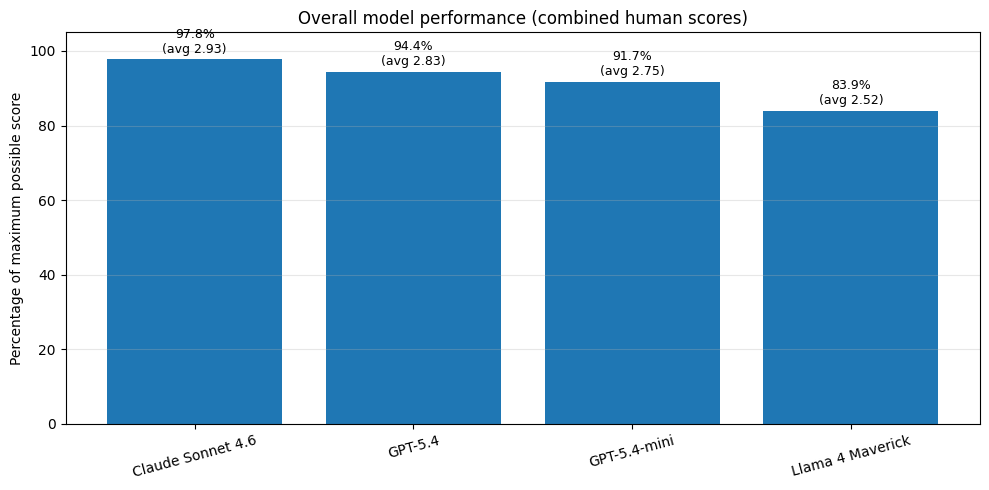

In [5]:

plot_df = overall_model.copy()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(plot_df["model_clean"], plot_df["pct_of_max"])
ax.set_title("Overall model performance (combined human scores)")
ax.set_ylabel("Percentage of maximum possible score")
ax.set_ylim(0, 105)
ax.grid(axis="y", alpha=0.3)

for bar, value, avg in zip(bars, plot_df["pct_of_max"], plot_df["avg_score"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.1f}%\n(avg {avg:.2f})",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



## 4. Individual scorer comparison

The combined ranking is important, but your project also becomes more interesting when we separate the two human scorers.

This section shows:
- how **Fatih** scored each model,
- how **Ömer Faruk** scored each model,
- and whether one scorer was systematically stricter or more generous.


In [6]:

by_scorer_model = (
    combined.groupby(["scorer_name", "model_clean"])["score"]
    .mean()
    .unstack()
    .reindex(index=["Fatih", "Ömer Faruk"])
)
by_scorer_pct = by_scorer_model / 3 * 100

display(Markdown("### Average score by scorer and model"))
display(by_scorer_model.round(3))

display(Markdown("### Percentage of maximum score by scorer and model"))
display(by_scorer_pct.round(2))

overall_by_scorer = combined.groupby("scorer_name")["score"].mean().to_frame("avg_score")
overall_by_scorer["pct_of_max"] = overall_by_scorer["avg_score"] / 3 * 100
display(Markdown("### Overall strictness / generosity"))
display(overall_by_scorer.round(3))


### Average score by scorer and model

model_clean,Claude Sonnet 4.6,GPT-5.4,GPT-5.4-mini,Llama 4 Maverick
scorer_name,,,,
Fatih,3.000,2.800,2.6,2.300
Ömer Faruk,2.867,2.867,2.9,2.733


### Percentage of maximum score by scorer and model

model_clean,Claude Sonnet 4.6,GPT-5.4,GPT-5.4-mini,Llama 4 Maverick
scorer_name,,,,
Fatih,100.00,93.33,86.67,76.67
Ömer Faruk,95.56,95.56,96.67,91.11


### Overall strictness / generosity

,avg_score,pct_of_max
scorer_name,,
Fatih,2.675,89.167
Ömer Faruk,2.842,94.722


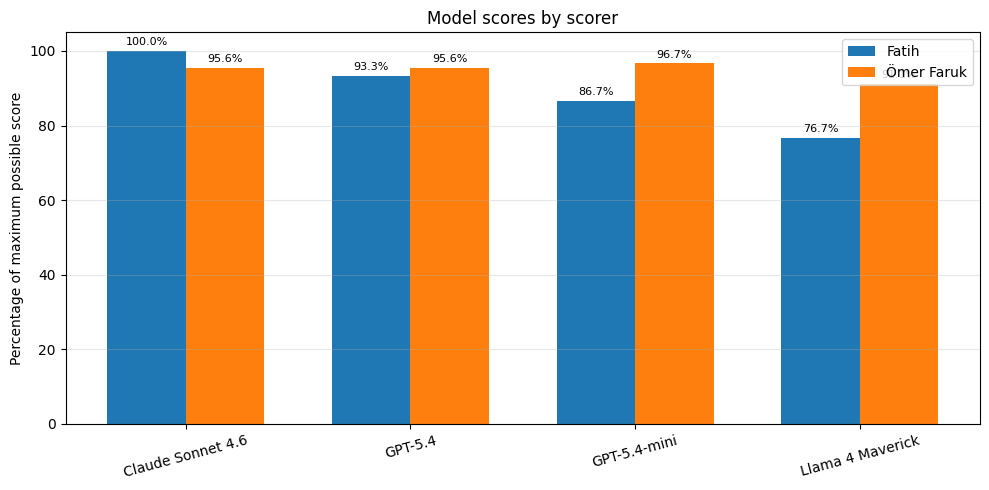

In [7]:

plot_df = by_scorer_pct.T.copy()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(plot_df.index))
width = 0.35

bars1 = ax.bar(x - width/2, plot_df["Fatih"], width, label="Fatih")
bars2 = ax.bar(x + width/2, plot_df["Ömer Faruk"], width, label="Ömer Faruk")

ax.set_title("Model scores by scorer")
ax.set_ylabel("Percentage of maximum possible score")
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=15)
ax.set_ylim(0, 105)
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()



## 5. How similar were the two human scorers?

This is one of the most important parts of the notebook.

The goal is not only to rank models, but also to understand whether the two evaluators saw the answers in a similar way.

### Metrics used
- **Exact agreement:** both scorers gave the same score.
- **Within 1 point:** even if different, the scores were at most 1 point apart.
- **Mean absolute difference:** average size of the disagreement.
- **Cohen's kappa:** a stricter agreement metric that adjusts for chance agreement.


In [8]:

agreement_summary = pd.DataFrame({
    "Metric": [
        "Exact agreement rate",
        "Within 1 point agreement rate",
        "Mean absolute difference",
        "Fatih average score",
        "Ömer Faruk average score",
        "Cohen's kappa (unweighted)",
        "Cohen's kappa (quadratic weighted)",
    ],
    "Value": [
        (merged["abs_diff"] == 0).mean(),
        (merged["abs_diff"] <= 1).mean(),
        merged["abs_diff"].mean(),
        merged["score_fatih"].mean(),
        merged["score_omer"].mean(),
        cohen_kappa_score(merged["score_fatih"], merged["score_omer"]),
        cohen_kappa_score(merged["score_fatih"], merged["score_omer"], weights="quadratic"),
    ]
})
display(agreement_summary.round(3))

diff_distribution = merged["diff"].value_counts().sort_index().rename_axis("Fatih - Ömer").to_frame("count")
display(Markdown("### Distribution of differences"))
display(diff_distribution)


,Metric,Value
0,Exact agreement rate,0.733
1,Within 1 point agreement rate,1.000
2,Mean absolute difference,0.267
3,Fatih average score,2.675
4,Ömer Faruk average score,2.842
5,Cohen's kappa (unweighted),0.280
6,Cohen's kappa (quadratic weighted),0.380


### Distribution of differences

,count
Fatih - Ömer,
-1,26
0,88
1,6


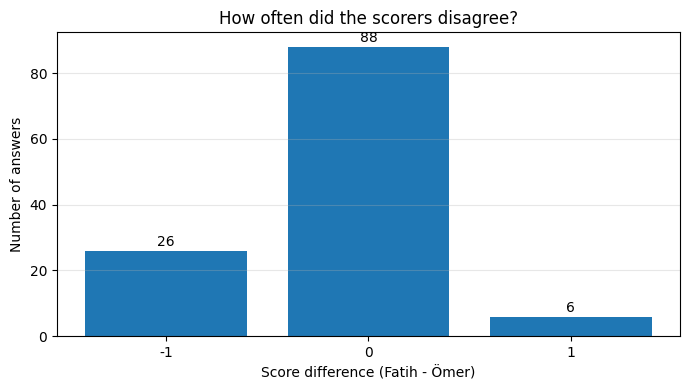

In [9]:

fig, ax = plt.subplots(figsize=(7, 4))
diff_counts = merged["diff"].value_counts().sort_index()
bars = ax.bar(diff_counts.index.astype(str), diff_counts.values)
ax.set_title("How often did the scorers disagree?")
ax.set_xlabel("Score difference (Fatih - Ömer)")
ax.set_ylabel("Number of answers")
ax.grid(axis="y", alpha=0.3)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5, f"{int(h)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


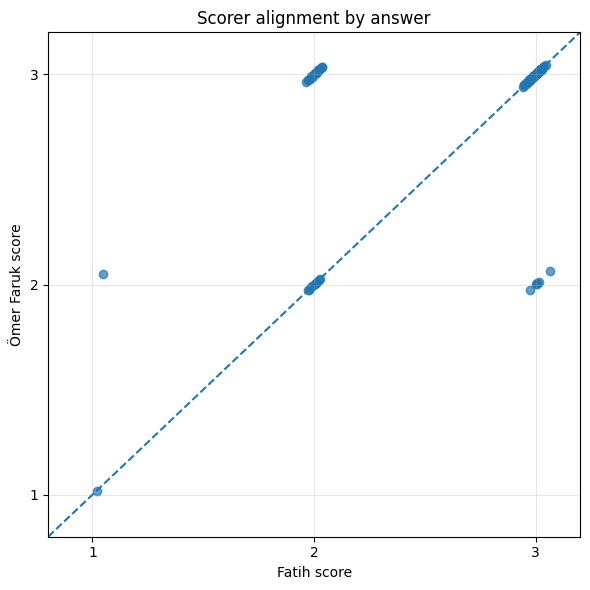

In [10]:

jitter = np.random.default_rng(42).normal(0, 0.03, size=len(merged))
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(merged["score_fatih"] + jitter, merged["score_omer"] + jitter, alpha=0.7)
ax.plot([0.8, 3.2], [0.8, 3.2], linestyle="--")
ax.set_xlim(0.8, 3.2)
ax.set_ylim(0.8, 3.2)
ax.set_xticks([1, 2, 3])
ax.set_yticks([1, 2, 3])
ax.set_xlabel("Fatih score")
ax.set_ylabel("Ömer Faruk score")
ax.set_title("Scorer alignment by answer")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



### Which model created the most scorer disagreement?

A very interesting angle is whether disagreement came from the scorers themselves, or from **specific models** producing more borderline answers.


In [11]:

agreement_by_model = (
    merged.groupby("model_clean")
    .agg(
        exact_agreement_rate=("abs_diff", lambda s: (s == 0).mean()),
        within_1_rate=("abs_diff", lambda s: (s <= 1).mean()),
        mean_abs_diff=("abs_diff", "mean"),
        fatih_avg=("score_fatih", "mean"),
        omer_avg=("score_omer", "mean")
    )
    .sort_values("mean_abs_diff", ascending=False)
)
display(agreement_by_model.round(3))


,exact_agreement_rate,within_1_rate,mean_abs_diff,fatih_avg,omer_avg
model_clean,,,,,
Llama 4 Maverick,0.500,1.0,0.500,2.3,2.733
GPT-5.4-mini,0.700,1.0,0.300,2.6,2.900
GPT-5.4,0.867,1.0,0.133,2.8,2.867
Claude Sonnet 4.6,0.867,1.0,0.133,3.0,2.867


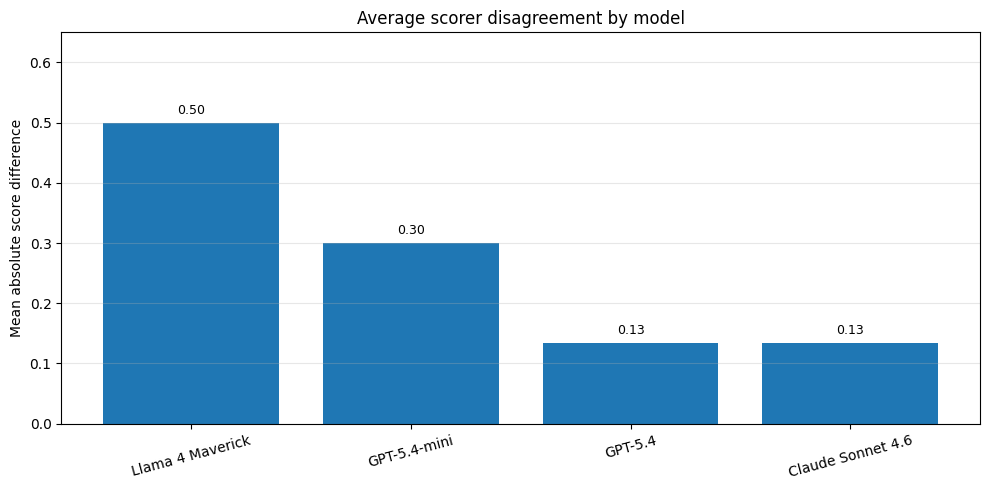

In [12]:

plot_df = agreement_by_model.reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(plot_df["model_clean"], plot_df["mean_abs_diff"])
ax.set_title("Average scorer disagreement by model")
ax.set_ylabel("Mean absolute score difference")
ax.set_ylim(0, max(plot_df["mean_abs_diff"]) + 0.15)
ax.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["mean_abs_diff"]):
    ax.text(bar.get_x() + bar.get_width()/2, value + 0.01, f"{value:.2f}", ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 6. Model performance by programming language

Because your benchmark used a **fixed language split**, we can also compare model quality by topic:

- **Questions 1–10** -> Python
- **Questions 11–20** -> C#
- **Questions 21–30** -> Java

This section keeps the analysis simple and useful:
it shows **which model was best overall**, but also **which model looked strongest for each programming language**.

In [ ]:
def assign_language(question_number):
    if 1 <= question_number <= 10:
        return "Python"
    elif 11 <= question_number <= 20:
        return "C#"
    elif 21 <= question_number <= 30:
        return "Java"
    return "Other"

for df in (fatih, omer, combined):
    df["language"] = df["question_number"].apply(assign_language)

language_check = combined[["question_number", "language"]].drop_duplicates().sort_values("question_number")
display(Markdown("### Language mapping check"))
display(language_check.head(12))
display(language_check.tail(12))

In [ ]:
language_model_scores = (
    combined.groupby(["language", "model_clean"])["score"]
    .mean()
    .unstack()
    .reindex(["Python", "C#", "Java"])
)

language_model_pct = (language_model_scores / 3 * 100).round(1)

display(Markdown("### Average score per model and programming language"))
display(language_model_scores.round(2))

display(Markdown("### Percentage per model and programming language"))
display(language_model_pct)

best_language_models = (
    combined.groupby(["language", "model_clean"])["score"]
    .mean()
    .reset_index()
    .sort_values(["language", "score"], ascending=[True, False])
    .groupby("language")
    .head(1)
    .reset_index(drop=True)
    .rename(columns={"score": "avg_score"})
)

display(Markdown("### Best model inside each language"))
display(best_language_models.round(2))

In [ ]:
plot_df = language_model_scores.T
ax = plot_df.plot(kind="bar", figsize=(10, 5))
ax.set_title("LLM performance by programming language")
ax.set_xlabel("Model")
ax.set_ylabel("Average score (0-3)")
ax.set_ylim(0, 3.2)
ax.legend(title="Question language")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
rows = []
for model in language_model_scores.columns:
    scores = language_model_scores[model].dropna()
    rows.append({
        "model": model,
        "best_language": scores.idxmax(),
        "best_score": round(scores.max(), 2),
        "worst_language": scores.idxmin(),
        "worst_score": round(scores.min(), 2),
        "range_between_best_and_worst": round(scores.max() - scores.min(), 2),
    })

language_strengths = (
    pd.DataFrame(rows)
    .sort_values("range_between_best_and_worst", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Best vs worst language for each model"))
display(language_strengths)

gpt_python = language_model_scores.loc["Python", "GPT-5.4"]
gpt_java = language_model_scores.loc["Java", "GPT-5.4"]

display(Markdown(
    "### Quick interpretation\n\n"
    f"- **Claude Sonnet 4.6** was the strongest model in **all three languages**.\n"
    f"- **Java** was the best-performing language overall for the top models.\n"
    f"- **GPT-5.4** improved from **{gpt_python:.2f}** on Python to **{gpt_java:.2f}** on Java.\n"
    f"- **GPT-5.4-mini** stayed competitive and remained close to GPT-5.4 across the language split.\n"
    f"- **Llama 4 Maverick** was clearly stronger on **Python** than on **C#** or **Java**, which is one of the most interesting language-specific patterns in the benchmark."
))


## 7. Most interesting findings

This section extracts the parts that are likely the most valuable for your final report, portfolio, or presentation.

In [16]:

question_texts = combined[["question_number", "question"]].drop_duplicates().set_index("question_number")["question"]

top_disagreement_questions = question_disagreement.head(10).reset_index()
top_disagreement_questions["question_preview"] = (
    top_disagreement_questions["question_number"]
    .map(question_texts)
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 140)
    + "..."
)

display(top_disagreement_questions[["question_number", "mean_abs_diff", "exact_agreement_rate", "question_preview"]].round(3))

model_question = (
    combined.groupby(["question_number", "model_clean"])["score"]
    .mean()
    .reset_index()
    .sort_values("score")
)
lowest_model_question = model_question.head(12).copy()
lowest_model_question["question_preview"] = (
    lowest_model_question["question_number"]
    .map(question_texts)
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 120)
    + "..."
)
display(Markdown("### Lowest-scoring model/question combinations"))
display(lowest_model_question)


,question_number,mean_abs_diff,exact_agreement_rate,question_preview
0,6,0.75,0.25,"Question: I am trying to remove items from a dictionary while looping over it, but I get an error. Code: data = {""a""..."
1,8,0.75,0.25,"Question: I am using recursion, but my program crashes with a maximum recursion depth error. Code: def count_down(n)..."
2,9,0.75,0.25,"Question: I am using a list as a default argument in a function, but the list keeps growing every time I call the fu..."
3,11,0.50,0.50,"Question: I am trying to change a variable inside a method, but the value does not change outside the method. Code: ..."
4,12,0.50,0.50,"Question: I have a list of values, and I want to print all items to the console. Code: using System; using System.Co..."
5,15,0.50,0.50,Question: I am getting a NullReferenceException when trying to access an object. Code: using System; class Person { ...
6,20,0.50,0.50,"Question: My ASP.NET API method returns data, but I do not see the expected result in the response. Code: using Micr..."
7,26,0.50,0.50,"Question: I have an ArrayList of objects, and I want to sort them based on one of their attributes. Code: import jav..."
8,27,0.50,0.50,"Question: I am trying to add a new element to an array, but it does not work as expected. Code: public class Main { ..."
9,30,0.50,0.50,"Question: After upgrading my Spring Boot application, one of my REST endpoints returns 404 when I call it with a tra..."


### Lowest-scoring model/question combinations

,question_number,model_clean,score,question_preview
79,20,Llama 4 Maverick,1.0,"Question: My ASP.NET API method returns data, but I do not see the expected result in the response. Code: using Micr..."
119,30,Llama 4 Maverick,1.5,"Question: After upgrading my Spring Boot application, one of my REST endpoints returns 404 when I call it with a tra..."
1,1,GPT-5.4,2.0,"Question: I have a list with duplicate values, and I want to remove the duplicates. Code: my_list = [1, 2, 2, 3, 4, ..."
2,1,GPT-5.4-mini,2.0,"Question: I have a list with duplicate values, and I want to remove the duplicates. Code: my_list = [1, 2, 2, 3, 4, ..."
74,19,GPT-5.4-mini,2.0,"Question: I am using a LINQ query, but it returns no results even though I expect some data. Code: using System; usi..."
73,19,GPT-5.4,2.0,"Question: I am using a LINQ query, but it returns no results even though I expect some data. Code: using System; usi..."
39,10,Llama 4 Maverick,2.0,"Question: I defined a route in my Flask app, but when I open it in the browser, I still get a 404 error. Code: from ..."
77,20,GPT-5.4,2.0,"Question: My ASP.NET API method returns data, but I do not see the expected result in the response. Code: using Micr..."
75,19,Llama 4 Maverick,2.0,"Question: I am using a LINQ query, but it returns no results even though I expect some data. Code: using System; usi..."
111,28,Llama 4 Maverick,2.0,"Question: I am using recursion, but my program crashes with a StackOverflowError. Code: public class Main { static v..."



## 8. Final interpretation

The last cell turns the numbers into direct conclusions.  
These conclusions are based on the actual scoring results in the uploaded files.

In [ ]:

best_row = overall_model.iloc[0]
worst_row = overall_model.iloc[-1]

fatih_avg = merged["score_fatih"].mean()
omer_avg = merged["score_omer"].mean()
exact_agreement = (merged["abs_diff"] == 0).mean() * 100
within_1 = (merged["abs_diff"] <= 1).mean() * 100
mean_abs_diff = merged["abs_diff"].mean()

key_findings = f"""
### Executive summary

**1. Best overall model**
- **{best_row['model_clean']}** performed best overall with an average score of **{best_row['avg_score']:.2f} / 3**
- That equals **{best_row['pct_of_max']:.1f}%** of the maximum possible score

**2. Worst overall model**
- **{worst_row['model_clean']}** performed worst overall with an average score of **{worst_row['avg_score']:.2f} / 3**
- That equals **{worst_row['pct_of_max']:.1f}%** of the maximum possible score

**3. Were the two scorers very different?**
- Not really.
- Exact agreement happened on **{exact_agreement:.1f}%** of all answers
- Agreement within 1 point happened on **{within_1:.1f}%** of all answers
- The average disagreement size was only **{mean_abs_diff:.2f} points**

**4. Who was stricter?**
- **Fatih** was stricter overall with an average score of **{fatih_avg:.2f}**
- **Ömer Faruk** was more generous overall with an average score of **{omer_avg:.2f}**

**5. Most interesting pattern**
- The biggest scorer disagreement did **not** come from random chaos.
- The largest model-specific disagreement came from **Llama 4 Maverick**, which had the highest average scorer gap

**6. Strong project insight**
- The ranking is especially interesting because the **budget model (GPT-5.4-mini)** stayed surprisingly strong.
- It did **not** beat the top model overall, but it remained much closer to the frontier models than the open-source model did.
- That makes the cost-versus-quality comparison meaningful for your project.


### Short conclusion

Your project already produces a useful real-world benchmark story:

- **Claude Sonnet 4.6** was the strongest model in this human evaluation
- **Llama 4 Maverick** was the weakest overall and also the most disagreement-prone
- **GPT-5.4-mini** was a very interesting budget performer
- **Fatih and Ömer Faruk were mostly aligned**, with only mild score differences
- The scorer differences are real, but they are **small enough that the overall ranking still looks trustworthy**
"""

display(Markdown(key_findings))



### Executive summary

**1. Best overall model**
- **Claude Sonnet 4.6** performed best overall with an average score of **2.93 / 3**
- That equals **97.8%** of the maximum possible score

**2. Worst overall model**
- **Llama 4 Maverick** performed worst overall with an average score of **2.52 / 3**
- That equals **83.9%** of the maximum possible score

**3. Were the two scorers very different?**
- Not really.
- Exact agreement happened on **73.3%** of all answers
- Agreement within 1 point happened on **100.0%** of all answers
- The average disagreement size was only **0.27 points**

**4. Who was stricter?**
- **Fatih** was stricter overall with an average score of **2.67**
- **Ömer Faruk** was more generous overall with an average score of **2.84**

**5. Most interesting pattern**
- The biggest scorer disagreement did **not** come from random chaos.
- It mostly came from a limited set of borderline questions, especially **Question 6**
- The largest model-specific disagreement came from **Llama 4 Maverick**, which had the highest average scorer gap

**6. Strong project insight**
- The ranking is especially interesting because the **budget model (GPT-5.4-mini)** stayed surprisingly strong.
- It did **not** beat the top model overall, but it remained much closer to the frontier models than the open-source model did.
- That makes the cost-versus-quality comparison meaningful for your project.

**7. Hardest and easiest questions**
- The hardest question overall was **Question 20** with an average score of **2.00**
- The easiest question overall was **Question 21** with an average score of **3.00**

### Short conclusion

Your project already produces a useful real-world benchmark story:

- **Claude Sonnet 4.6** was the strongest model in this human evaluation
- **Llama 4 Maverick** was the weakest overall and also the most disagreement-prone
- **GPT-5.4-mini** was a very interesting budget performer
- **Fatih and Ömer Faruk were mostly aligned**, with only mild score differences
- The scorer differences are real, but they are **small enough that the overall ranking still looks trustworthy**



## 9. Why this notebook is useful for the project

This notebook gives you a strong evidence artifact for the analysis phase of the StackEval recreation:
- it shows the final benchmark results clearly,
- it compares two human scorers instead of hiding subjectivity,
- it identifies the strongest and weakest models,
- and it translates raw scores into interpretable findings for a professional portfolio.

It is also a good bridge between:
- **LO1 / Analysing** -> understanding model performance,
- **LO2 / Advising** -> explaining which model should be preferred and why,
- **LO5 / Managing** -> monitoring quality, disagreement, and weak spots in the benchmark results.